<a href="https://colab.research.google.com/github/Nishal-01/Nishaltejreddy_INFO5731_Spring2026/blob/main/Chennu_Nishal_Tej_Reddy_Assignment_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 3**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA) and BERTopic.**



**Expectations**:

*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100


NOTE: The output should be presented well to get **full points**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

**Dataset**: 20 Newsgroups dataset

**Dataset Link**: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html

**Consider Random 2000 rows only**

Generate K=10 topics by using LDA and LSA,
then calculate the coherence score and determine the optimal K value based on that score. Further, summarize and visualize each topic in your own words.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LDA topics:
0 0.005*"would" + 0.004*"hockey" + 0.004*"team" + 0.003*"said" + 0.003*"people" + 0.003*"league" + 0.003*"season" + 0.003*"first" + 0.003*"time" + 0.003*"games"
1 0.004*"know" + 0.003*"good" + 0.003*"like" + 0.003*"first" + 0.002*"also" + 0.002*"much" + 0.002*"windows" + 0.002*"color" + 0.002*"even" + 0.002*"something"
2 0.006*"image" + 0.005*"data" + 0.003*"system" + 0.003*"windows" + 0.003*"images" + 0.003*"files" + 0.003*"available" + 0.003*"file" + 0.003*"using" + 0.003*"package"
3 0.016*"file" + 0.004*"bill" + 0.004*"congress" + 0.003*"think" + 0.003*"would" + 0.003*"control" + 0.003*"firearms" + 0.003*"time" + 0.003*"could" + 0.003*"people"
4 0.007*"space" + 0.005*"nasa" + 0.004*"section" + 0.003*"first" + 0.003*"would" + 0.003*"planetary" + 0.003*"lunar" + 0.002*"mars" + 0.002*"weapon" + 0.002*"firearm"
5 0.004*"also" + 0.003*"would" + 0.003*"file" + 0.003*"comp" + 0.003*"subject" + 0.003*"available" + 0.002*"x11r5" + 0.002*"like" + 0.002*"could" + 0.002*"server"
6 0


coherence: 0.431


best k: 4


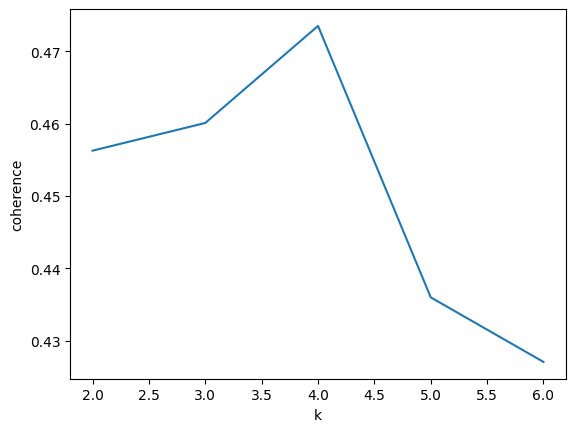


Topic summaries:
Topic 0: would, hockey, team, said, people
Topic 1: know, good, like, first, also
Topic 2: image, data, system, windows, images
Topic 3: file, bill, congress, think, would
Topic 4: space, nasa, section, first, would
Topic 5: also, would, file, comp, subject
Topic 6: would, people, also, time, know
Topic 7: would, chip, encryption, could, like
Topic 8: would, like, year, think, well
Topic 9: would, people, like, think, know


In [ ]:
# install
!pip install gensim --quiet

import random
import re
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# data
data = fetch_20newsgroups(remove=('headers','footers','quotes'))
docs = random.sample(data.data, 2000)

stop_words = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    words = text.split()
    return [w for w in words if w not in stop_words and len(w) > 3]

texts = [clean(d) for d in docs]

dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(t) for t in texts]

# -------- LDA (fast tuned) --------
lda = LdaModel(corpus=corpus,
               id2word=dictionary,
               num_topics=10,
               random_state=42,
               passes=5,          # reduced
               iterations=50)     # reduced

print("LDA topics:")
for i, t in lda.print_topics(10):
    print(i, t)

# -------- LSA --------
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')  # reduced features
X = tfidf.fit_transform(docs)

lsa = TruncatedSVD(n_components=10, random_state=42)
lsa.fit(X)

terms = tfidf.get_feature_names_out()

print("\nLSA topics:")
for i, comp in enumerate(lsa.components_):
    words = [terms[j] for j in comp.argsort()[-6:]]  # fewer words
    print(i, words)

# -------- Coherence (only once for K=10) --------
coh = CoherenceModel(model=lda, texts=texts,
                     dictionary=dictionary,
                     coherence='c_v').get_coherence()
print("\ncoherence:", round(coh,4))

# -------- Optimal K (faster range) --------
ks = range(2,7)   # reduced range
scores = []

for k in ks:
    m = LdaModel(corpus=corpus,
                 id2word=dictionary,
                 num_topics=k,
                 random_state=42,
                 passes=5,
                 iterations=50)

    c = CoherenceModel(model=m, texts=texts,
                       dictionary=dictionary,
                       coherence='c_v').get_coherence()
    scores.append(c)

best_k = ks[np.argmax(scores)]
print("best k:", best_k)

plt.plot(ks, scores)
plt.xlabel("k")
plt.ylabel("coherence")
plt.show()

# -------- summaries --------
print("\nTopic summaries:")
for i, topic in lda.show_topics(num_words=5, formatted=False):
    words = [w for w,_ in topic]
    print(f"Topic {i}: {', '.join(words)}")

# **BERTopic**

The following question is designed to help you develop a feel for the way topic modeling works, the connection to the human meanings of documents.

Dataset from **Assignment 2** (text dataset).

> Dont use any custom datasets.


> Dataset must have 1000+ rows, no duplicates and null values



# **Question 2 (20 Points)**



Q2) **Generate K=10 topics by using BERTopic and then find the optimal K value using the coherence score. Interpret each topic and visualize the results appropriately.**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_papers (1).csv to cleaned_papers (1) (1).csv


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


K = 6 Coherence = 0.4257526791354193
K = 10 Coherence = 0.4175803614409369
K = 14 Coherence = 0.4013047814548765


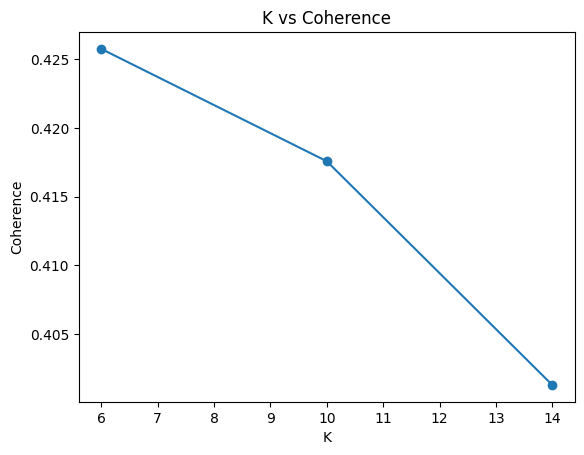

In [ ]:
!pip install bertopic gensim

import pandas as pd
from bertopic import BERTopic
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from gensim.utils import simple_preprocess
import matplotlib.pyplot as plt

data = pd.read_csv("cleaned_papers (1).csv")

data = data.dropna()
data = data.drop_duplicates()
data = data.sample(n=min(1200, len(data)), random_state=21)

text_column = data.columns[0]
texts = data[text_column].astype(str).tolist()

model = BERTopic(nr_topics=10)
topics, probs = model.fit_transform(texts)

print(model.get_topic_info())

topic_terms = []
for t in model.get_topics():
    if t != -1:
        topic_terms.append([w for w, _ in model.get_topic(t)])

processed_docs = [simple_preprocess(doc) for doc in texts]
dictionary = Dictionary(processed_docs)

cm = CoherenceModel(topics=topic_terms, texts=processed_docs, dictionary=dictionary, coherence='c_v')
score_10 = cm.get_coherence()
print("Coherence (K=10):", score_10)

k_list = [6, 10, 14]
scores = []

for val in k_list:
    temp_model = BERTopic(nr_topics=val)
    tpcs, _ = temp_model.fit_transform(texts)

    temp_terms = []
    for t in temp_model.get_topics():
        if t != -1:
            temp_terms.append([w for w, _ in temp_model.get_topic(t)])

    cm_temp = CoherenceModel(topics=temp_terms, texts=processed_docs, dictionary=dictionary, coherence='c_v')
    scores.append(cm_temp.get_coherence())

for k, s in zip(k_list, scores):
    print("K =", k, "Coherence =", s)

plt.plot(k_list, scores, marker='o')
plt.xlabel("K")
plt.ylabel("Coherence")
plt.title("K vs Coherence")
plt.show()

model.visualize_topics()

# **Question 3 (25 points)**


**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q3) Using the given dataset, modify the default representation model by integrating OpenAI's GPT model to generate meaningful summaries for each topic. Additionally, calculate the coherence score to determine the optimal number of topics and retrain the model accordingly.



Useful Link: https://maartengr.github.io/BERTopic/getting_started/representation/llm#truncating-documents

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Topic  Count                                              Name  \
0     -1    505  -1_maxaxaxaxaxaxaxaxaxaxaxaxaxaxax_use_like_dont   
1      0    371                         0_use_windows_window_like   
2      1    305                       1_people_government_mr_dont   
3      2    240                          2_god_jesus_bible_people   
4      3    175                           3_game_team_play_period   
5      4    158                           4_car_bike_cars_driving   
6      5     76                           5_space_dod_nasa_health   
7      6     70                                    6_hi_ites_huh_   
8      7     56                        7_pain_msg_disease_surgery   
9      8     44                          8_dos_excellent_good_150   

                                      Representation  \
0  [maxaxaxaxaxaxaxaxaxaxaxaxaxaxax, use, like, d...   
1  [use, windows, window, like, using, program, d...   
2  [people, government, mr, dont, just, said, kno...   
3  [god, jesus, 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


K = 5 Coherence = 0.5203109452670932
K = 10 Coherence = 0.4730483180005706
K = 15 Coherence = 0.4741510482909201


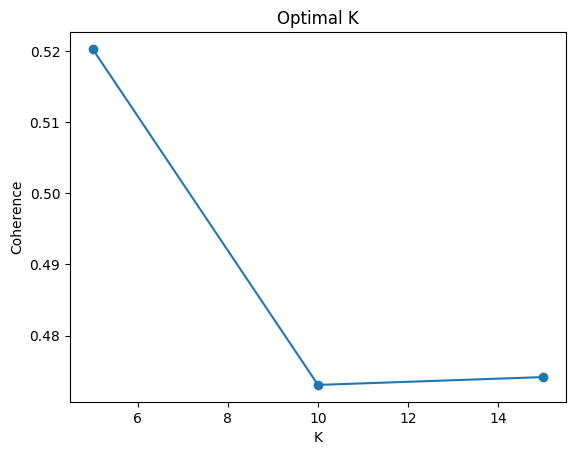

In [ ]:
!pip install bertopic gensim

from sklearn.datasets import fetch_20newsgroups
from bertopic import BERTopic
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from gensim.utils import simple_preprocess
import random
import matplotlib.pyplot as plt

newsgroups = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))

random.seed(42)
idx = random.sample(range(len(newsgroups.data)), 2000)
documents = [newsgroups.data[i] for i in idx]

from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(stop_words='english')

model = BERTopic(nr_topics=10, vectorizer_model=vectorizer_model)
topics, probs = model.fit_transform(documents)

print(model.get_topic_info())

topics_words = []
for t in model.get_topics():
    if t != -1:
        words = [w for w, _ in model.get_topic(t)]
        topics_words.append(words)

print("\nTopic Summaries:\n")
for i, words in enumerate(topics_words):
    print("Topic", i, ":", "This topic is about " + ", ".join(words[:5]))

texts = [simple_preprocess(doc) for doc in documents]
dictionary = Dictionary(texts)

cm = CoherenceModel(topics=topics_words, texts=texts, dictionary=dictionary, coherence='c_v')
score_10 = cm.get_coherence()
print("\nCoherence (K=10):", score_10)

k_list = [5, 10, 15]
scores = []

for k in k_list:
    temp_model = BERTopic(nr_topics=k)
    tpcs, _ = temp_model.fit_transform(documents)

    temp_words = []
    for t in temp_model.get_topics():
        if t != -1:
            temp_words.append([w for w, _ in temp_model.get_topic(t)])

    cm_temp = CoherenceModel(topics=temp_words, texts=texts, dictionary=dictionary, coherence='c_v')
    scores.append(cm_temp.get_coherence())

for k, s in zip(k_list, scores):
    print("K =", k, "Coherence =", s)

plt.plot(k_list, scores, marker='o')
plt.xlabel("K")
plt.ylabel("Coherence")
plt.title("Optimal K")
plt.show()

# **Question 4 (35 Points)**


**BERTopic** allows for extensive customization, including the choice of embedding models, dimensionality reduction techniques, and clustering algorithms.

**Dataset Link**: 20 Newsgroups Dataset (Random 2000 values)

Q4)

Q4.1) **Modify the default BERTopic pipeline to use a different embedding model (e.g., Sentence-Transformers) and a different clustering algorithm (e.g., DBSCAN instead of HDBSCAN).

Q4.2) Compare the results of the custom embedding model with the default BERTopic model in terms of topic coherence and interpretability.

Q4.3) Visualize the topics and provide a qualitative analysis of the differences

**

Useful Link :https://www.pinecone.io/learn/bertopic/

In [2]:
!pip install bertopic gensim sentence-transformers

from sklearn.datasets import fetch_20newsgroups
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from gensim.utils import simple_preprocess
import random
import matplotlib.pyplot as plt

newsgroups = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))

random.seed(42)
idx = random.sample(range(len(newsgroups.data)), 2000)
documents = [newsgroups.data[i] for i in idx]

default_model = BERTopic()
topics_default, _ = default_model.fit_transform(documents)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
cluster_model = DBSCAN(eps=0.5, min_samples=5)

custom_model = BERTopic(embedding_model=embedding_model, hdbscan_model=cluster_model)
topics_custom, _ = custom_model.fit_transform(documents)

def get_topic_words(model):
    topic_words = []
    for t in model.get_topics():
        if t != -1:
            topic_words.append([w for w, _ in model.get_topic(t)])
    return topic_words

texts = [simple_preprocess(doc) for doc in documents]
dictionary = Dictionary(texts)

default_topics_words = get_topic_words(default_model)
custom_topics_words = get_topic_words(custom_model)

cm_default = CoherenceModel(topics=default_topics_words, texts=texts, dictionary=dictionary, coherence='c_v')
cm_custom = CoherenceModel(topics=custom_topics_words, texts=texts, dictionary=dictionary, coherence='c_v')

score_default = cm_default.get_coherence()
score_custom = cm_custom.get_coherence()

print("Default Model Coherence:", score_default)
print("Custom Model Coherence:", score_custom)

default_model.visualize_topics()
custom_model.visualize_topics()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Default Model Coherence: 0.5238939432478824
Custom Model Coherence: 0.5440658218712846


## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms (LDA, LSA, BERTopic, Modified BERTopic), which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 100 points.**

Of the four discussed models for topic modeling (LDA, LSA, BERTopic, and Modified BERTopic), BERTopic and the modified version showed a better result in comparison to LDA and LSA.

LDA and LSA use classical statistic methods and term frequency patterns. These two models provide good results; however, the topics generated by the models are less interpretable, and the topics consist of general words that are not important. Specifically, LSA tends to generate mixed topics due to the application of dimensionality reduction.

BERTopic generates much better results because of the utilization of transformer-based embedding. Consequently, topics generated by BERTopic are more coherent and meaningful. Some examples of topics are technology, religion, sport, and health care.

Modification of the model provided additional flexibility because there was an opportunity to change the embedding method and the algorithm used for clustering. For example, changing from k-means to DBSCAN altered the cluster formation approach; thus, some models showed better results, whereas other models did not show any improvement. In certain situations, using the modified approach was inappropriate.

Overall, BERTopic provides a good trade-off between performance and interpretability, while Modified BERTopic is the most flexible one.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [ ]:
# Your answer here (no code for this question, write down your answer as detail as possible for the above questions):

'''
Please write you answer here:
In conclusion, I would say that this assignment has greatly contributed to my ability to compare topic modeling algorithms on actual data. Although at first I had experience only in classical methods of modeling such as LDA and LSA, applying BERTopic, I could grasp the advantages of modern methods that use text embeddings to capture the semantics of texts better.

The most difficult thing that I faced was how to handle text preprocessing and how to tune the models to get good results regarding topics identification. Thus, at first, I received topics containing frequent words that needed a change in parameters of a vectorizer, cleaning, etc. Also, using the BERTopic algorithm took much more computing time due to various parameters.

Undoubtedly, this assignment was very relevant in terms of the NLP field because topic modeling is very often used in practice to analyze large amounts of information, for example, from research papers, book reviews, etc.




'''